<a href="https://colab.research.google.com/github/arkadeepsadhukhan-sketch/arkaD-ARIMA/blob/main/arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q yfinance

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 5)

In [ ]:
from datetime import datetime

nifty = yf.download(
    "^NSEI",
    start="2015-01-01",
    end=datetime.today().strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=False
)

nifty = nifty[["Open", "High", "Low", "Close", "Volume"]]

print(f"Dataset Shape : {nifty.shape}")

nifty.head()

Dataset Shape : (2834, 5)


Price,Open,High,Low,Close,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800


In [ ]:
# Flatten column names if required
if isinstance(nifty.columns, pd.MultiIndex):
    nifty.columns = nifty.columns.get_level_values(0)

print(nifty.columns)

nifty.head()

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800


In [ ]:
nifty.isnull().sum()

,0
Price,
Open,0
High,0
Low,0
Close,0
Volume,0


In [ ]:
nifty.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,2834.0,14971.371880,5954.148655,7023.649902,9949.049805,12197.824707,19463.512695,2.633370e+04
High,2834.0,15039.883941,5977.566864,7034.200195,9995.712158,12242.200195,19521.474609,2.637320e+04
Low,2834.0,14881.647173,5930.677805,6825.799805,9893.462402,12150.725098,19380.562988,2.621005e+04
Close,2834.0,14962.189565,5954.640455,6970.600098,9952.950195,12207.875000,19438.575195,2.632855e+04
Volume,2834.0,326258.080452,187022.700676,0.000000,203300.000000,272200.000000,395500.000000,1.811000e+06


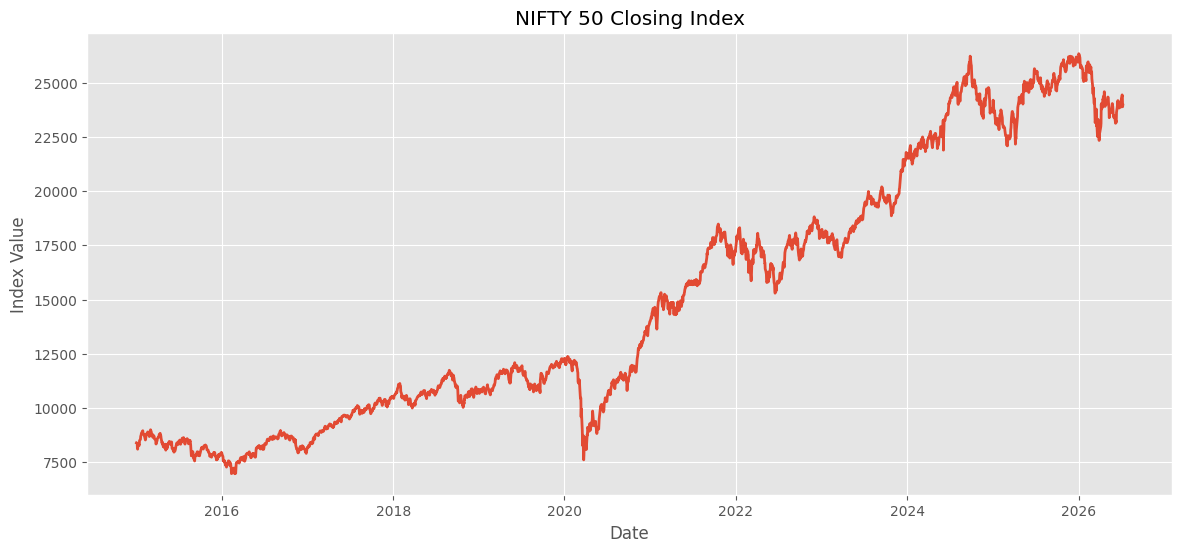

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    nifty.index,
    nifty["Close"],
    linewidth=2
)

plt.title("NIFTY 50 Closing Index")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()

In [ ]:
print(nifty.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2834 entries, 2015-01-02 to 2026-07-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2834 non-null   float64
 1   High    2834 non-null   float64
 2   Low     2834 non-null   float64
 3   Close   2834 non-null   float64
 4   Volume  2834 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 132.8 KB
None


In [ ]:
train_size = int(len(nifty) * 0.85)

train = nifty.iloc[:train_size].copy()
test = nifty.iloc[train_size:].copy()

print(f"Training observations : {len(train)}")
print(f"Testing observations  : {len(test)}")

Training observations : 2408
Testing observations  : 426


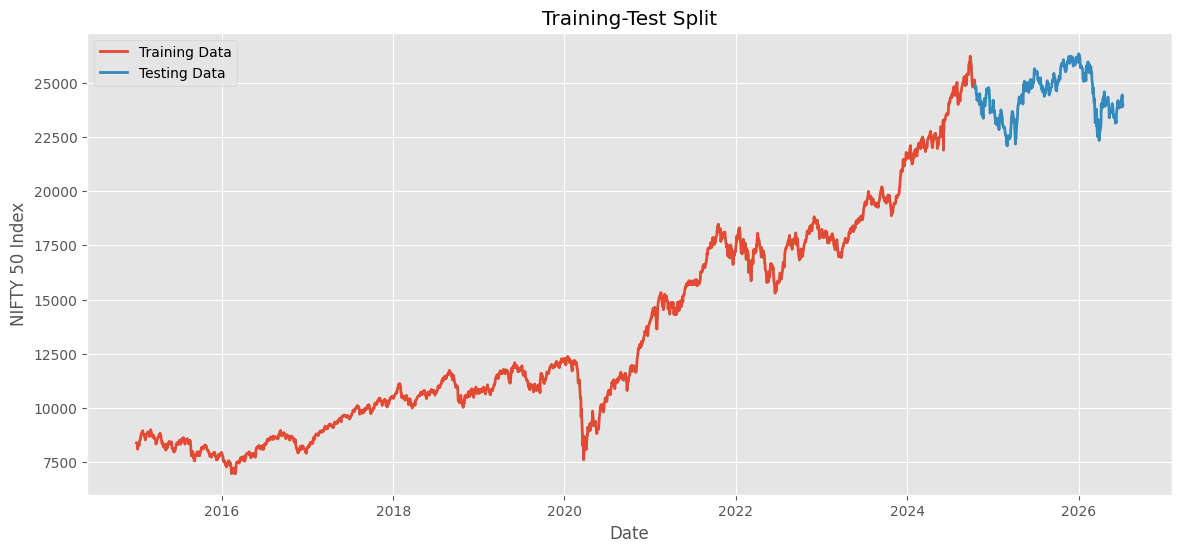

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["Close"], label="Training Data", linewidth=2)
plt.plot(test.index, test["Close"], label="Testing Data", linewidth=2)

plt.title("Training-Test Split")
plt.xlabel("Date")
plt.ylabel("NIFTY 50 Index")

plt.legend()

plt.show()

In [ ]:
train_series = train["Close"]
test_series = test["Close"]

In [ ]:
result = adfuller(train_series)

print(f"ADF Statistic : {result[0]:.4f}")
print(f"P-value       : {result[1]:.4f}")
print()

for key, value in result[4].items():
    print(f"Critical Value ({key}) : {value:.4f}")

ADF Statistic : 1.1484
P-value       : 0.9956

Critical Value (1%) : -3.4331
Critical Value (5%) : -2.8627
Critical Value (10%) : -2.5674


In [ ]:
if result[1] < 0.05:
    print("The training series is stationary.")
else:
    print("The training series is non-stationary.")

The training series is non-stationary.


In [ ]:
if result[1] >= 0.05:
    train_diff = train_series.diff().dropna()
    d = 1
else:
    train_diff = train_series.copy()
    d = 0

print(f"Differencing Order (d) = {d}")

Differencing Order (d) = 1


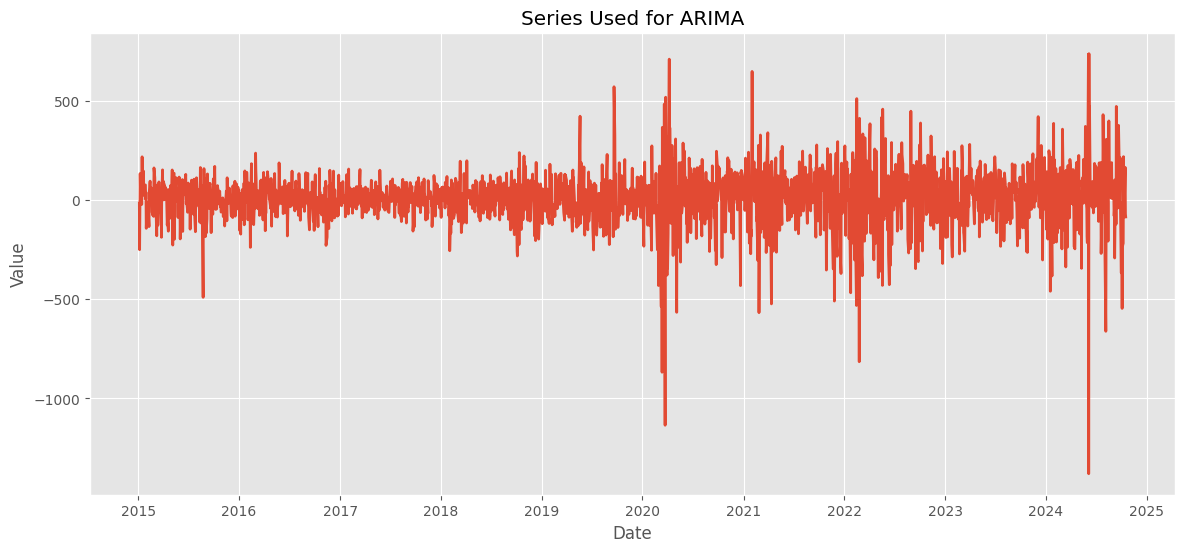

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(train_diff, linewidth=2)

plt.title("Series Used for ARIMA")
plt.xlabel("Date")
plt.ylabel("Value")

plt.show()

In [ ]:
result_diff = adfuller(train_diff)

print(f"ADF Statistic : {result_diff[0]:.4f}")
print(f"P-value       : {result_diff[1]:.4f}")
print()

for key, value in result_diff[4].items():
    print(f"Critical Value ({key}) : {value:.4f}")

ADF Statistic : -20.3613
P-value       : 0.0000

Critical Value (1%) : -3.4331
Critical Value (5%) : -2.8627
Critical Value (10%) : -2.5674


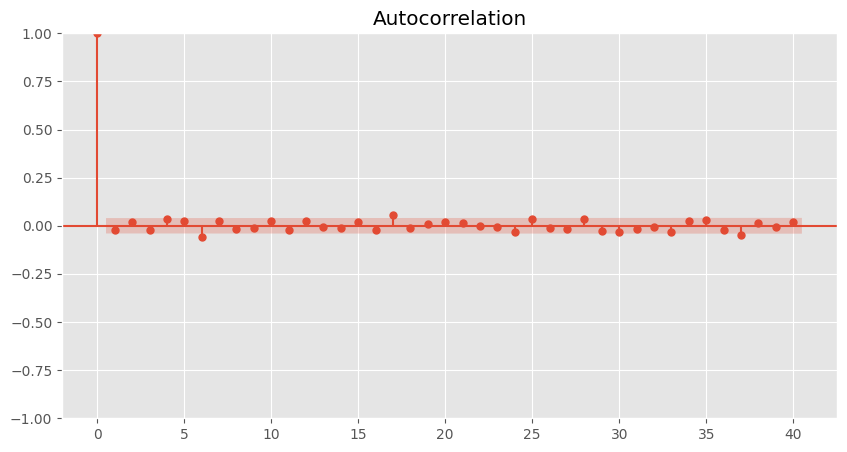

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

plot_acf(train_diff, lags=40, ax=ax)

plt.show()

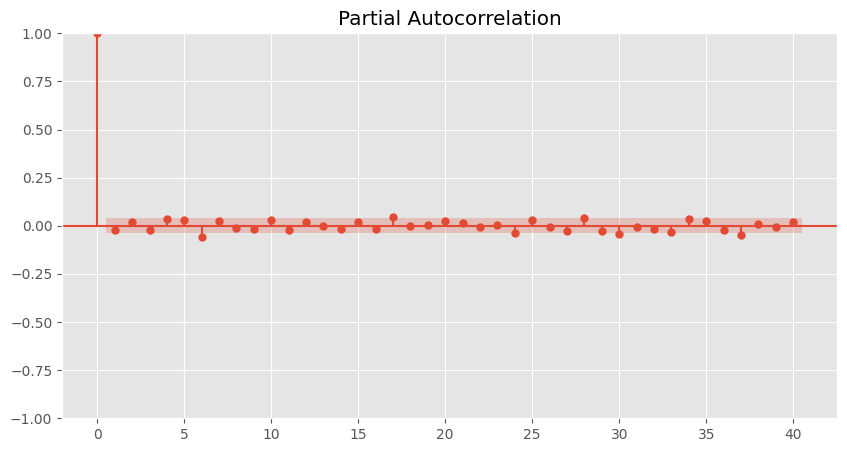

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

plot_pacf(train_diff, lags=40, method="ywm", ax=ax)

plt.show()

In [ ]:
print(f"""
Training observations : {len(train_series)}
Testing observations  : {len(test_series)}
Differencing Order    : {d}
""")


Training observations : 2408
Testing observations  : 426
Differencing Order    : 1



In [ ]:
candidate_models = [
    (1, d, 1),
    (1, d, 2),
    (2, d, 1),
    (2, d, 2),
    (3, d, 1),
    (3, d, 2)
]

In [ ]:
results.style.format({
    "AIC": "{:.2f}",
    "BIC": "{:.2f}"
})

,Order,AIC,BIC
0,"(2, 1, 2)",30422.19,30451.12
1,"(1, 1, 2)",30424.37,30447.51
2,"(2, 1, 1)",30424.42,30447.56
3,"(1, 1, 1)",30425.45,30442.81
4,"(3, 1, 1)",30425.93,30454.86
5,"(3, 1, 2)",30428.57,30463.28


In [ ]:
best_order = results.loc[0, "Order"]

print(f"Best ARIMA Order : {best_order}")

Best ARIMA Order : (2, 1, 2)


In [ ]:
model = ARIMA(train_series, order=best_order)

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2408
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -15206.095
Date:                Fri, 10 Jul 2026   AIC                          30422.190
Time:                        09:58:19   BIC                          30451.121
Sample:                             0   HQIC                         30432.714
                               - 2408                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4809      0.020    -24.287      0.000      -0.520      -0.442
ar.L2         -0.9740      0.021    -46.515      0.000      -1.015      -0.933
ma.L1          0.4909      0.021     23.081      0.0

In [ ]:
forecast = model_fit.get_forecast(
    steps=len(test_series)
)

forecast_mean = pd.Series(
    forecast.predicted_mean.to_numpy(),
    index=test_series.index,
    name="Forecast"
)

confidence_interval = forecast.conf_int()
confidence_interval.index = test_series.index

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


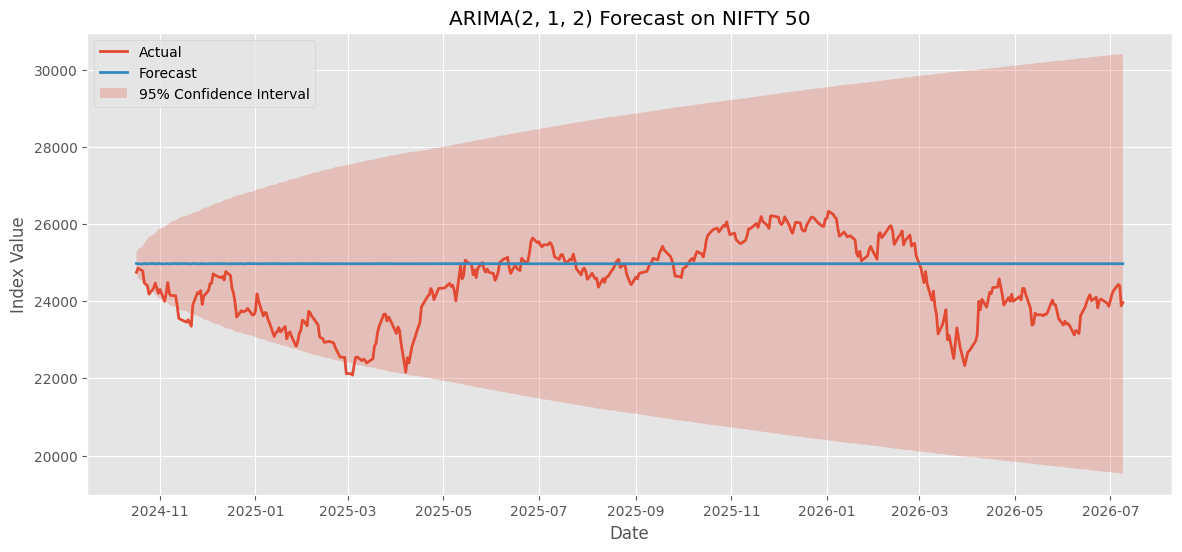

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    test_series.index,
    test_series,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_series.index,
    forecast_mean,
    label="Forecast",
    linewidth=2
)

plt.fill_between(
    test_series.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title(f"ARIMA{best_order} Forecast on NIFTY 50")

plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()

plt.show()

In [ ]:
forecast_df = pd.concat(
    [
        test_series.rename("Actual"),
        forecast_mean
    ],
    axis=1
)

forecast_df.head()

,Actual,Forecast
Date,,
2024-10-17,24749.849609,24976.147809
2024-10-18,24854.050781,24966.463509
2024-10-21,24781.099609,24966.399338
2024-10-22,24472.099609,24975.863039
2024-10-23,24435.500000,24971.374624


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(test_series, forecast_mean)

rmse = np.sqrt(
    mean_squared_error(test_series, forecast_mean)
)

mape = mean_absolute_percentage_error(
    test_series,
    forecast_mean
)

In [ ]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [
        mae,
        rmse,
        mape * 100
    ]
})

metrics.style.format({"Value": "{:.2f}"})

,Metric,Value
0,MAE,919.56
1,RMSE,1130.66
2,MAPE,3.85


In [ ]:
residuals = test_series - forecast_mean

residuals.head()

,0
Date,
2024-10-17,-226.298200
2024-10-18,-112.412728
2024-10-21,-185.299729
2024-10-22,-503.763430
2024-10-23,-535.874624


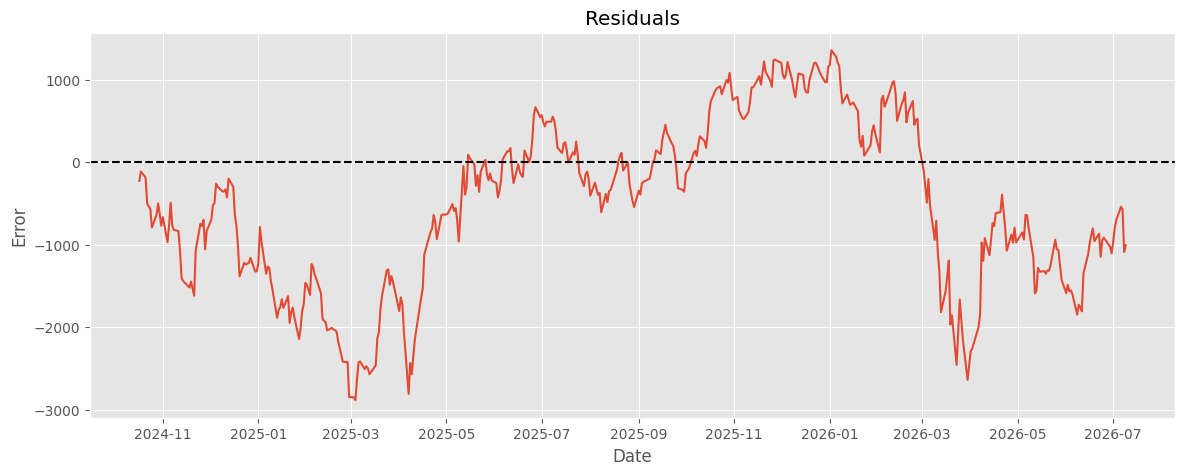

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(residuals, linewidth=1.5)

plt.axhline(0, color="black", linestyle="--")

plt.title("Residuals")
plt.xlabel("Date")
plt.ylabel("Error")

plt.show()

In [ ]:
from statsmodels.graphics.gofplots import qqplot

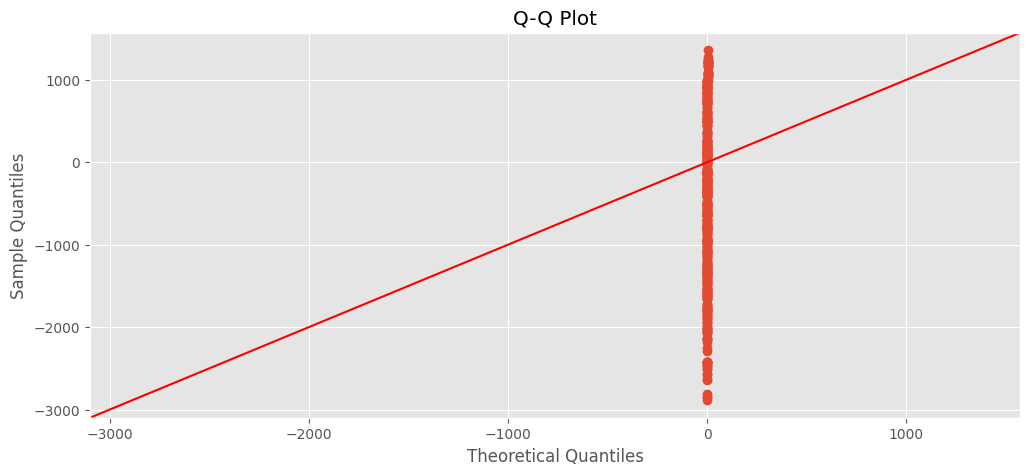

In [ ]:
qqplot(residuals, line="45")

plt.title("Q-Q Plot")

plt.show()

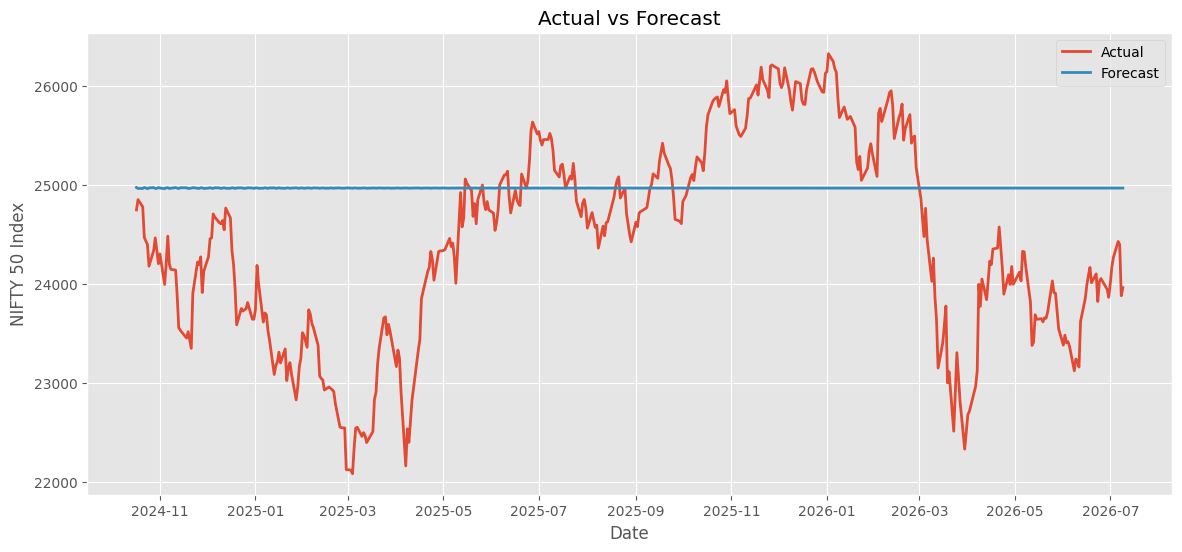

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    test_series.index,
    test_series,
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    linewidth=2
)

plt.title("Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("NIFTY 50 Index")

plt.legend()

plt.show()

***Conclusion***

This project developed an ARIMA-based forecasting framework for the NIFTY 50 index using more than ten years of historical daily market data obtained through the Yahoo Finance API. Prior to model development, the time series was examined for stationarity using the Augmented Dickey–Fuller (ADF) test, and first-order differencing was applied where required. Several candidate ARIMA models were compared using the Akaike Information Criterion (AIC), with ARIMA(2,1,2) providing the best balance between model fit and complexity.

The selected model achieved a Mean Absolute Error (MAE) of 919.56, Root Mean Squared Error (RMSE) of 1130.66, and a Mean Absolute Percentage Error (MAPE) of 3.85% on the test data. While the model produced reasonable short-term forecasts, the predictions remained relatively smooth compared with the observed market movements. This behaviour reflects a well-known limitation of classical ARIMA models when applied to financial markets, where price movements are strongly influenced by external events, changing market sentiment, and nonlinear dynamics.

Residual analysis further indicated that the forecast errors were not completely random and did not closely follow a normal distribution, suggesting that additional market structure remains unexplained by the model. Future work may explore more advanced forecasting approaches such as SARIMA, GARCH, Prophet, or deep learning models to better capture seasonality, volatility, and nonlinear relationships in financial time series.